# 1. Data Collecting

In [2]:
!pip install kaggle -q

import os, shutil
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pywt
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Setup Kaggle API key
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

PyTorch 2.10.0+cpu | CUDA: False


In [2]:
# Download dataset kaggle
!kaggle datasets download -d arunrk7/surface-crack-detection --unzip -p data/

Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors




  0%|          | 0.00/233M [00:00<?, ?B/s]
  0%|          | 1.00M/233M [00:01<05:41, 713kB/s]
  1%|          | 2.00M/233M [00:01<03:09, 1.28MB/s]
  1%|▏         | 3.00M/233M [00:02<02:05, 1.92MB/s]
  2%|▏         | 5.00M/233M [00:02<01:01, 3.90MB/s]
  3%|▎         | 6.00M/233M [00:02<00:50, 4.75MB/s]
  3%|▎         | 8.00M/233M [00:02<00:35, 6.65MB/s]
  4%|▍         | 10.0M/233M [00:02<00:28, 8.12MB/s]
  5%|▌         | 12.0M/233M [00:02<00:25, 9.19MB/s]
  6%|▌         | 14.0M/233M [00:02<00:23, 9.65MB/s]
  7%|▋         | 16.0M/233M [00:03<00:24, 9.12MB/s]
  7%|▋         | 17.0M/233M [00:03<00:32, 6.94MB/s]
  8%|▊         | 19.0M/233M [00:03<00:25, 8.72MB/s]
  9%|▉         | 21.0M/233M [00:03<00:23, 9.34MB/s]
 10%|▉         | 23.0M/233M [00:04<00:23, 9.40MB/s]
 11%|█         | 25.0M/233M [00:04<00:21, 10.1MB/s]
 12%|█▏        | 27.0M/233M [00:04<00:20, 10.7MB/s]
 12%|█▏        | 29.0M/233M [00:04<00:21, 9.80MB/s]
 13%|█▎        | 31.0M/233M [00:04<00:20, 10.4MB/s]
 14%|█▍        | 33.0

In [3]:
SEED = 42
CLASS_MAP = {'Negative': 0, 'Positive': 1}

paths, labels = [], []
for cls, lbl in CLASS_MAP.items():
    for f in os.listdir(f'data/{cls}'):
        paths.append(f'data/{cls}/{f}')
        labels.append(lbl)

# Split ke 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(paths, labels, test_size=0.3, stratify=labels, random_state=SEED)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

# Simpan ke CSV 
os.makedirs('data/splits', exist_ok=True)
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    pd.DataFrame({'path': X, 'label': y}).to_csv(f'data/splits/{name}.csv', index=False)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 28000 | Val: 6000 | Test: 6000


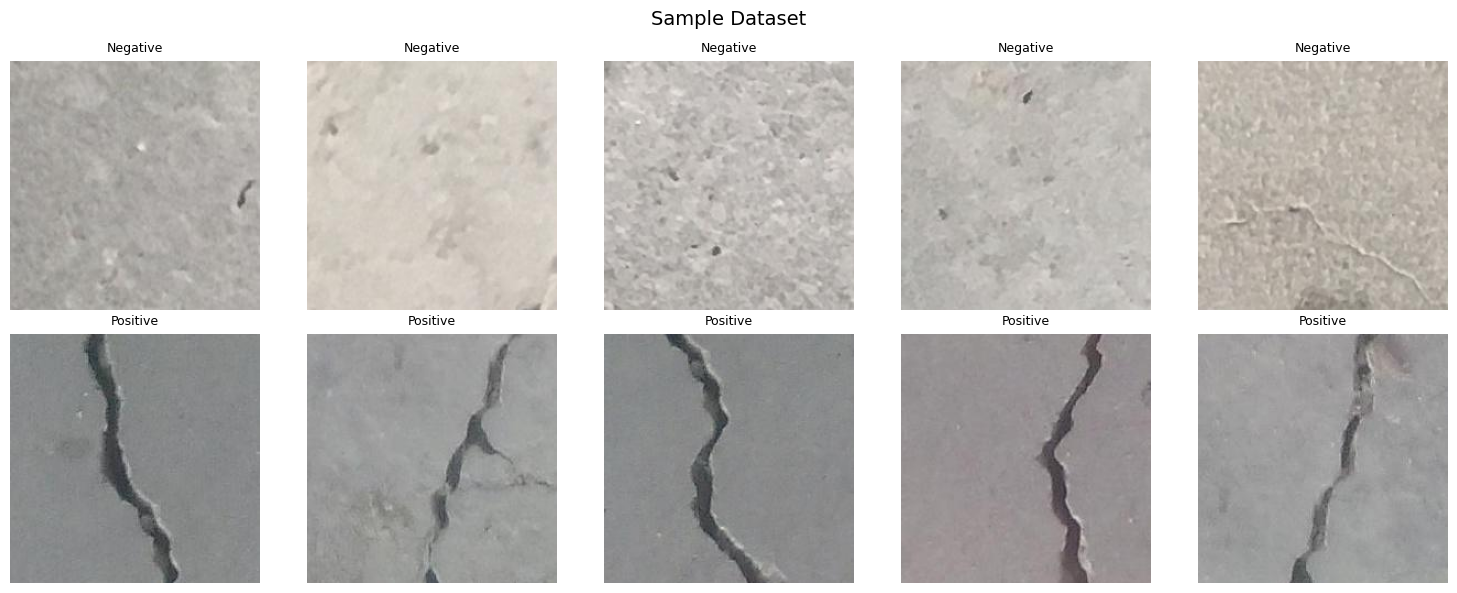

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Dataset', fontsize=14)

for i, cls in enumerate(['Negative', 'Positive']):
    samples = os.listdir(f'data/{cls}')[:5]
    for j, fname in enumerate(samples):
        img = Image.open(f'data/{cls}/{fname}')
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(cls, fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# 2. Pre-Processing
Dalam pre-processing ini kita melakukan:
1. Mengubah gambar menjadi grayscale
2. Resize ke 128x128
3. Normalisasi rentang 0 - 1
4. Augmentasi (Flip, Rotasi, Brighness, Contrass)

In [4]:
IMG_SIZE   = 128
BATCH_SIZE = 32

train_transform = T.Compose([
    T.Grayscale(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2),
    T.ToTensor(),
    T.Lambda(lambda x: x + 0.02 * torch.randn_like(x))  # gaussian noise
])

val_test_transform = T.Compose([
    T.Grayscale(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])


class CrackDataset(Dataset):
    def __init__(self, csv_path, transform):
        df = pd.read_csv(csv_path)
        self.paths, self.labels = df['path'].tolist(), df['label'].tolist()
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)


train_loader = DataLoader(CrackDataset('data/splits/train.csv', train_transform),    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(CrackDataset('data/splits/val.csv',   val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(CrackDataset('data/splits/test.csv',  val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verifikasi
imgs, lbls = next(iter(train_loader))
print(f'Shape: {imgs.shape} | Range: [{imgs.min():.2f}, {imgs.max():.2f}] | Labels: {lbls[:8].tolist()}')

Shape: torch.Size([32, 1, 128, 128]) | Range: [-0.08, 1.04] | Labels: [0, 0, 1, 0, 0, 1, 0, 0]


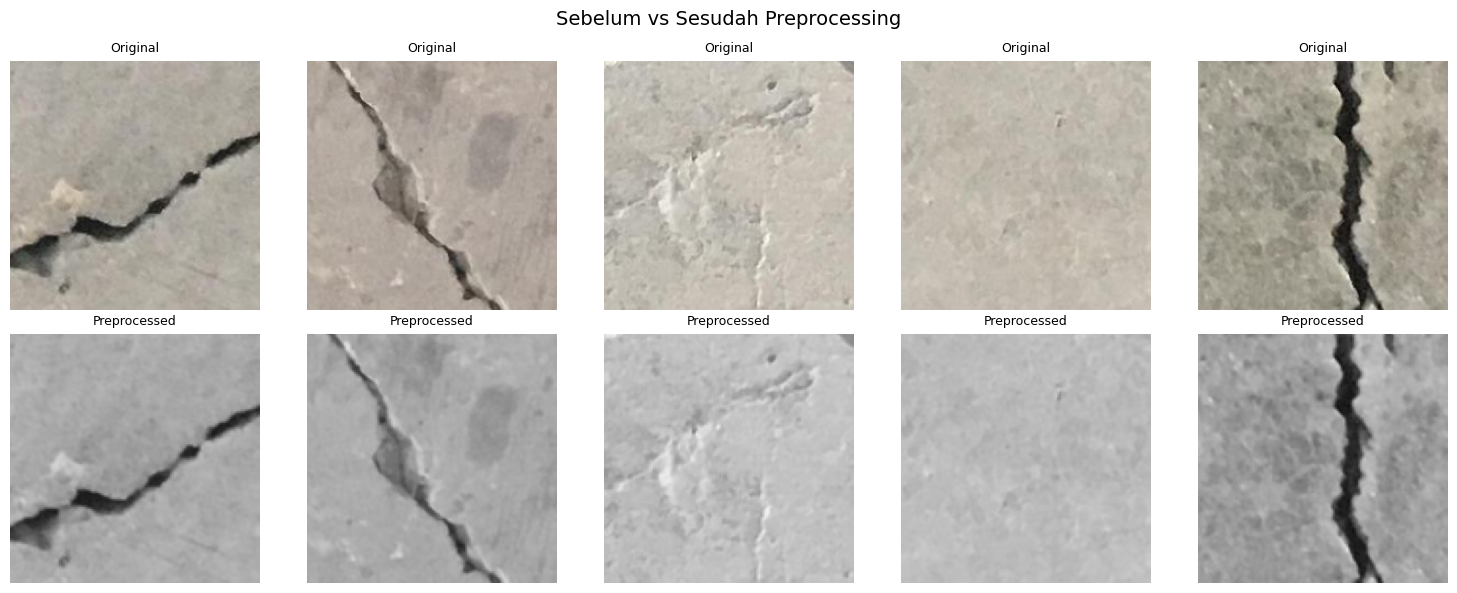

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sebelum vs Sesudah Preprocessing', fontsize=14)

for j in range(5):
    # Sebelum — gambar asli RGB
    raw = Image.open(X_train[j])
    axes[0, j].imshow(raw)
    axes[0, j].set_title('Original', fontsize=9)
    axes[0, j].axis('off')

    # Sesudah — hasil preprocessing (grayscale, resize, normalized)
    preprocessed = val_test_transform(raw).squeeze(0).numpy()
    axes[1, j].imshow(preprocessed, cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title('Preprocessed', fontsize=9)
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

# 3. Wavelet Transform

In [ ]:
import pywt

def apply_dwt(tensor_img):
    # tensor_img shape: [1, 128, 128] → ambil array 2D
    img = tensor_img.squeeze(0).numpy()  # [128, 128]

    # Level 1 DWT → hasilkan LL1, (LH1, HL1, HH1)
    LL1, (LH1, HL1, HH1) = pywt.dwt2(img, 'haar')

    # Level 2 DWT pada LL1 → hasilkan LL2, (LH2, HL2, HH2)
    LL2, (LH2, HL2, HH2) = pywt.dwt2(LL1, 'haar')

    # Stack 4 subband level 2 → shape [4, 32, 32]
    subbands = np.stack([LL2, LH2, HL2, HH2], axis=0)

    # Normalisasi per subband ke 0-1
    for i in range(4):
        min_val, max_val = subbands[i].min(), subbands[i].max()
        subbands[i] = (subbands[i] - min_val) / (max_val - min_val + 1e-8)

    return torch.tensor(subbands, dtype=torch.float32)  # [4, 32, 32]


# Update CrackDataset untuk apply DWT setelah transform
class CrackDatasetDWT(Dataset):
    def __init__(self, csv_path, transform):
        df = pd.read_csv(csv_path)
        self.paths, self.labels = df['path'].tolist(), df['label'].tolist()
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        tensor = self.transform(img)   # [1, 128, 128]
        wavelet = apply_dwt(tensor)    # [4, 32, 32]
        return wavelet, torch.tensor(self.labels[idx], dtype=torch.long)


train_loader = DataLoader(CrackDatasetDWT('data/splits/train.csv', train_transform),    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(CrackDatasetDWT('data/splits/val.csv',   val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(CrackDatasetDWT('data/splits/test.csv',  val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verifikasi
imgs, lbls = next(iter(train_loader))
print(f'Shape: {imgs.shape} | Range: [{imgs.min():.2f}, {imgs.max():.2f}] | Labels: {lbls[:8].tolist()}')

Shape: torch.Size([32, 4, 32, 32]) | Range: [0.00, 1.00] | Labels: [1, 0, 0, 0, 1, 0, 1, 1]


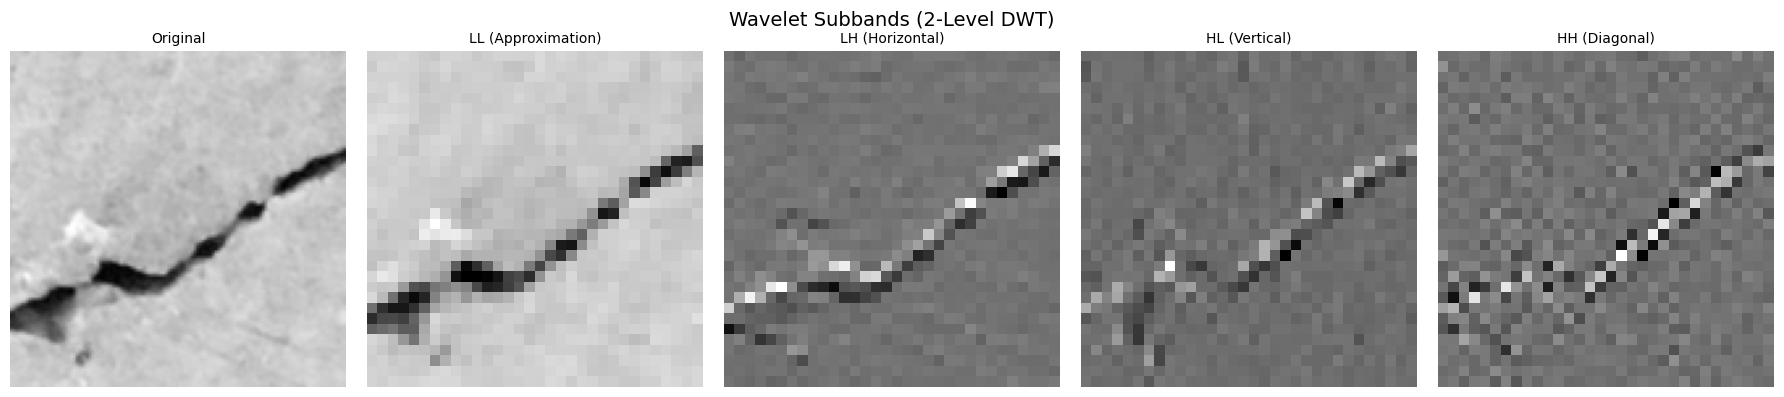

In [17]:
sample_img = Image.open(X_train[0])
sample_tensor = val_test_transform(sample_img)  # [1, 128, 128]
sample_wavelet = apply_dwt(sample_tensor)        # [4, 32, 32]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Wavelet Subbands (2-Level DWT)', fontsize=14)

axes[0].imshow(sample_tensor.squeeze(0), cmap='gray')
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

subband_names = ['LL (Approximation)', 'LH (Horizontal)', 'HL (Vertical)', 'HH (Diagonal)']
for i, name in enumerate(subband_names):
    axes[i+1].imshow(sample_wavelet[i], cmap='gray')
    axes[i+1].set_title(name, fontsize=10)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# 4. CNN Ringan (Custom CNN)

In [20]:
class LightCrackCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(4, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc    = nn.Linear(64, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = x.flatten(1)
        return self.fc(x)

model = LightCrackCNN()
print(model)
print(f'\nTotal parameter: {sum(p.numel() for p in model.parameters()):,}')

LightCrackCNN(
  (conv1): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total parameter: 24,082


In [22]:
import torch.optim as optim
from torchinfo import summary

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = LightCrackCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

summary(model, input_size=(1, 4, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
LightCrackCNN                            [1, 2]                    --
├─Sequential: 1-1                        [1, 16, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 16, 32, 32]           592
│    └─BatchNorm2d: 2-2                  [1, 16, 32, 32]           32
│    └─ReLU: 2-3                         [1, 16, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 32, 32, 32]           4,640
│    └─BatchNorm2d: 2-5                  [1, 32, 32, 32]           64
│    └─ReLU: 2-6                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-7                    [1, 32, 16, 16]           --
├─Sequential: 1-3                        [1, 64, 8, 8]             --
│    └─Conv2d: 2-8                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-9                  [1, 64, 16, 16]           128
│    └

In [31]:
from tqdm import tqdm

def train(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (model(imgs).argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            total_loss += criterion(out, labels).item()
            correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


# Training loop dengan early stopping
EPOCHS     = 30
PATIENCE   = 5
best_val   = float('inf')
wait       = 0
history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Early stopping
    if val_loss < best_val:
        best_val = val_loss
        wait     = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}')
            break

print('\nTraining selesai! Best model disimpan ke best_model.pth')

Epoch 01 | Train Loss: 0.0327 Acc: 0.9913 | Val Loss: 0.1837 Acc: 0.9527


Epoch 02 | Train Loss: 0.0259 Acc: 0.9936 | Val Loss: 0.2049 Acc: 0.9510


Epoch 03 | Train Loss: 0.0271 Acc: 0.9935 | Val Loss: 0.1092 Acc: 0.9708


Epoch 04 | Train Loss: 0.0253 Acc: 0.9944 | Val Loss: 0.0734 Acc: 0.9765


Epoch 05 | Train Loss: 0.0221 Acc: 0.9944 | Val Loss: 0.1020 Acc: 0.9762


...

Epoch 13 | Train Loss: 0.0153 Acc: 0.9964 | Val Loss: 0.1421 Acc: 0.9653


Epoch 14 | Train Loss: 0.0159 Acc: 0.9965 | Val Loss: 0.0367 Acc: 0.9905


Epoch 15 | Train Loss: 0.0168 Acc: 0.9960 | Val Loss: 0.0954 Acc: 0.9787


Epoch 16 | Train Loss: 0.0150 Acc: 0.9968 | Val Loss: 0.0417 Acc: 0.9913


Epoch 17 | Train Loss: 0.0127 Acc: 0.9970 | Val Loss: 0.0590 Acc: 0.9872

Early stopping triggered at epoch 17

Training selesai! Best model disimpan ke best_model.pth


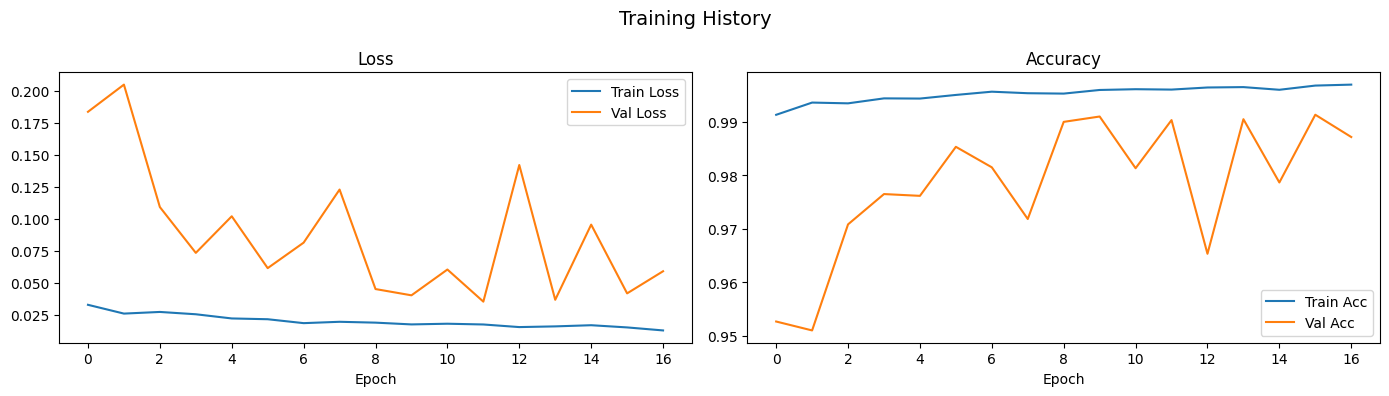

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training History', fontsize=14)

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Evaluation

              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99      3000
    Positive       0.99      0.99      0.99      3000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



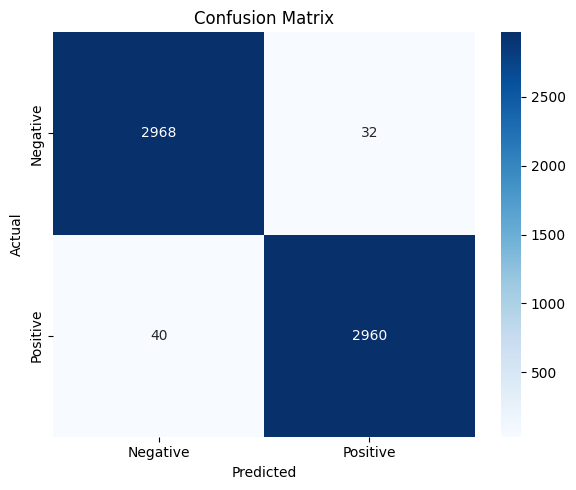

In [35]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

# Classification report
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

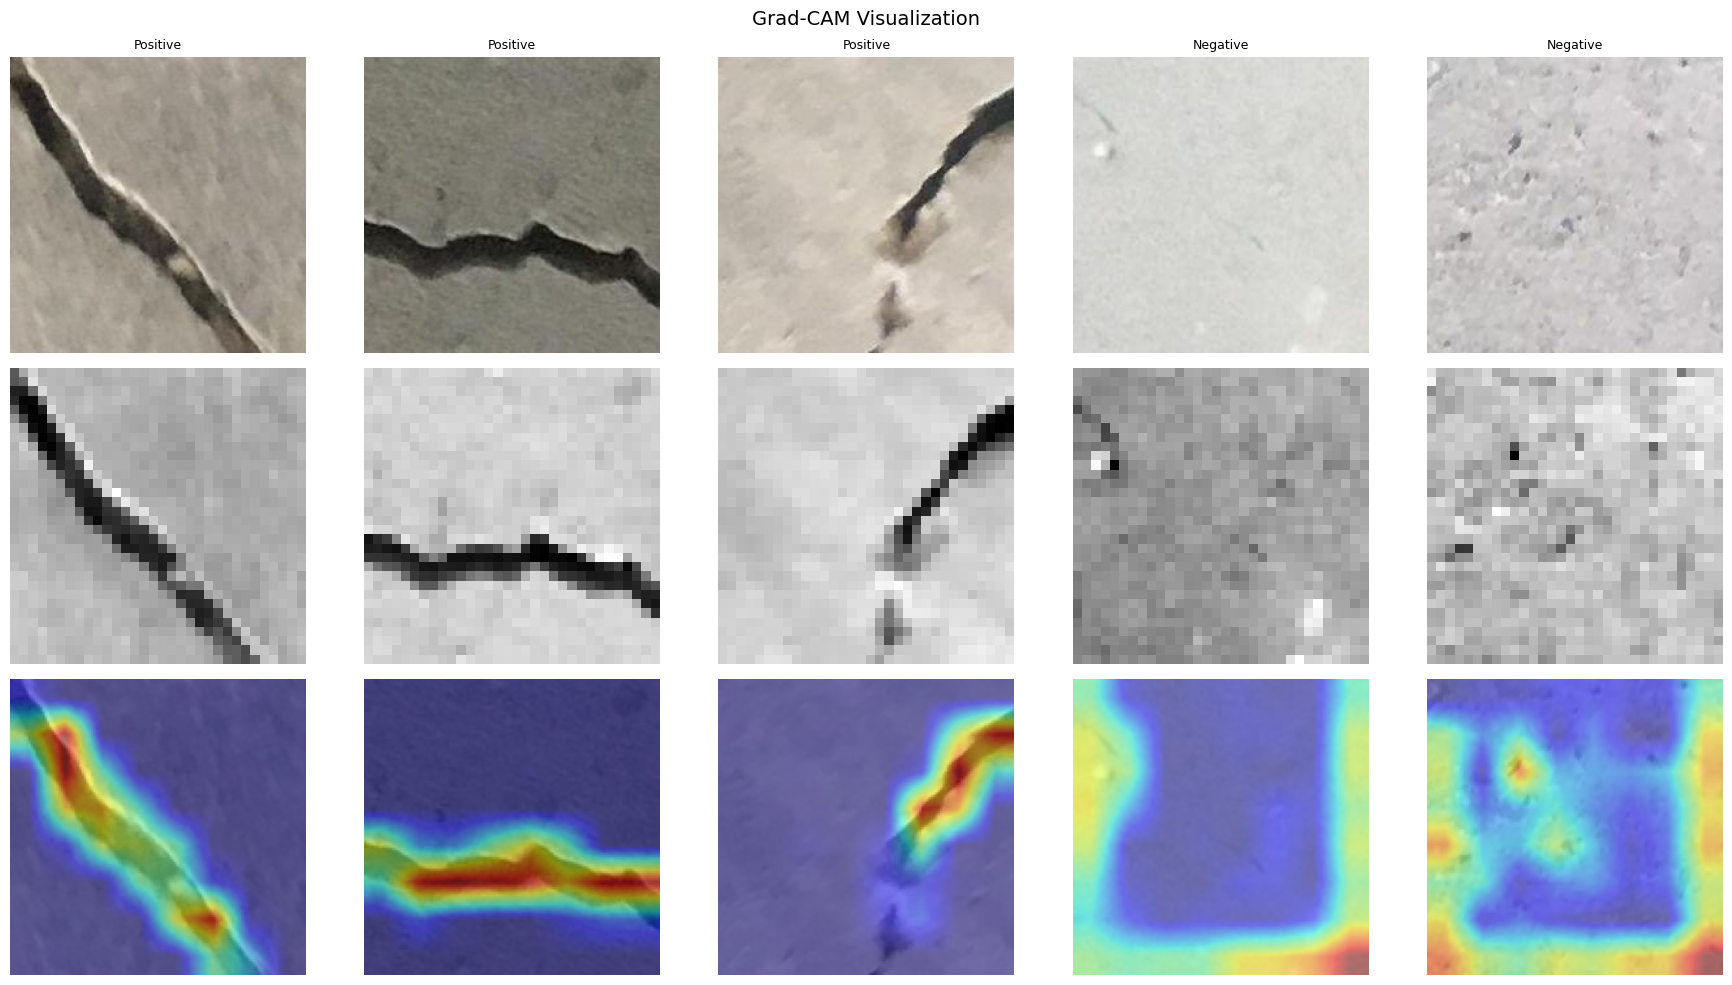

In [38]:
def get_gradcam(model, img_tensor, target_class=None):
    model.eval()
    features, grads = [], []

    # Hook untuk capture output dan gradient dari conv3
    handle_f = model.conv3.register_forward_hook(lambda m, i, o: features.append(o))
    handle_b = model.conv3.register_full_backward_hook(lambda m, i, o: grads.append(o[0]))

    # Forward pass
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    output = model(img_tensor)
    target = output.argmax(1) if target_class is None else torch.tensor([target_class])

    # Backward pass
    model.zero_grad()
    output[0, target].backward()

    # Hitung Grad-CAM
    weights  = grads[0].mean(dim=[2, 3], keepdim=True)   # global average pooling gradient
    gradcam  = (weights * features[0]).sum(dim=1).squeeze()
    gradcam  = F.relu(gradcam)                            # buang nilai negatif
    gradcam  = gradcam / (gradcam.max() + 1e-8)          # normalisasi 0-1

    handle_f.remove()
    handle_b.remove()

    return gradcam.detach().cpu().numpy()

test_dataset = CrackDatasetDWT('data/splits/test.csv', val_test_transform)

# Visualisasi Grad-CAM pada 5 sampel test
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Grad-CAM Visualization', fontsize=14)

rows = ['Original', 'Preprocessed', 'Grad-CAM Overlay']
for ax, row in zip(axes[:, 0], rows):
    ax.set_ylabel(row, fontsize=11)

for j in range(5):
    img_tensor, label = test_dataset[j]
    gradcam = get_gradcam(model, img_tensor)

    # Baris 1 — gambar asli
    raw = Image.open(test_dataset.paths[j])
    axes[0, j].imshow(raw)
    axes[0, j].set_title(f"{'Positive' if label == 1 else 'Negative'}", fontsize=9)
    axes[0, j].axis('off')

    # Baris 2 — gambar preprocessed
    axes[1, j].imshow(img_tensor[0], cmap='gray')
    axes[1, j].axis('off')

    # Baris 3 — Grad-CAM overlay
    import cv2
    gradcam_resized = cv2.resize(gradcam, (128, 128))
    heatmap = plt.cm.jet(gradcam_resized)[:, :, :3]
    overlay = 0.5 * np.array(raw.resize((128, 128))) / 255 + 0.5 * heatmap
    axes[2, j].imshow(overlay)
    axes[2, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import io, cv2
import ipywidgets as widgets
from IPython.display import display, Image as IPImage

uploader = widgets.FileUpload(accept='image/*', multiple=False)
btn      = widgets.Button(description='Analyze', button_style='primary')
out      = widgets.Output()

def on_click(b):
    out.clear_output()
    with out:
        file_bytes         = list(uploader.value.values())[0]['content']
        label, conf, overlay = predict_from_bytes(bytes(file_bytes))
        _, buf             = cv2.imencode('.jpg', overlay)
        print(f'Label: {label} | Confidence: {conf}%')
        display(IPImage(data=buf.tobytes()))

btn.on_click(on_click)
display(uploader, btn, out)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='primary', description='Analyze', style=ButtonStyle())

Output()

In [ ]:
def predict_from_bytes(image_bytes):
    img     = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    tensor  = val_test_transform(img)
    wavelet = apply_dwt(tensor)

    with torch.no_grad():
        output = model(wavelet.unsqueeze(0).to(DEVICE))

    probs      = F.softmax(output, dim=1)[0]
    label      = 'Positive' if probs.argmax().item() == 1 else 'Negative'
    confidence = probs.max().item()

    gradcam     = get_gradcam(wavelet)
    heatmap     = cv2.applyColorMap((gradcam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    img_resized = np.array(img.resize((128, 128)))
    overlay     = cv2.addWeighted(img_resized, 0.5, heatmap, 0.5, 0)

    return label, round(confidence * 100, 2), overlay